# Image clustering using GPT-4o

In [40]:
import pandas as pd
from pathlib import Path

from AI_representation_bias_in_farming import module5_extract_pic_feature_words

# import the megadata dataframe
megadata_file = Path("..") / "results" / "megadata" / "image_megadata.csv"
megadata = pd.read_csv(megadata_file, header=0)

# import manual cluster check note
manual_correction_file = Path("..") / "results" / "megadata" / "outlier_image_manual_correction.csv"
manual_correction = pd.read_csv(manual_correction_file, header=0)

# Create a list of outdoor values to check, combine these and call it all to be "outdoor"
outdoor_values = ['pasture', 'pasture_or_mud']
megadata["GPT4o_cluster"] = megadata["GPT4o_cluster"].replace(outdoor_values, "outdoor")\
    
# update the GPT4o_cluster based on my manual check results and cluster label corrections
megadata2 = pd.merge(megadata, manual_correction, on =("file", "GPT4o_cluster", "GPT4o_cluster_explanation"), how = "left")
megadata2['GPT4o_cluster'] = megadata2['GPT4o_cluster'].where(
    pd.isna(megadata2['change_to_cluster']), 
    megadata2['change_to_cluster']
)

# what's the percentage of images that got manually corrected? 
manual_pct = round(len(manual_correction)/len(megadata2), 5)
print(f"The percentage of images got manually corrected is: {manual_pct}")

# what's the percentage of images that got manually corrected? 
metal_railing_count = megadata2['manual_note'].str.contains('metal', na=False).sum()
unclear_count = megadata2['manual_note'].str.contains('unclear', na=False).sum()
other_image_count = len(megadata2[megadata2['GPT4o_cluster'] == "other"])
metal_railing_pct = round((metal_railing_count/other_image_count), 5)
unclear_pct = round((unclear_count/other_image_count), 5)
print(f"The percentage of images in the 'other' category that contains animals housed behind metal railings but are outdoors is: {metal_railing_pct}")
print(f"The percentage of images in the 'other' category, because the background is too unclear to judge is: {unclear_pct}")


The percentage of images got manually corrected is: 0.04773
The percentage of images in the 'other' category that contains animals housed behind metal railings but are outdoors is: 0.23543
The percentage of images in the 'other' category, because the background is too unclear to judge is: 0.13453


In [ ]:
# Set up base paths
source_base = Path("..") / "results"
dest_base = Path("..") / "results" / "cluster_post_manual_fix"

module5_extract_pic_feature_words.cluster_farm_images(
    megadata2,
    source_base,
    dest_base
)


In [41]:
# summary
cluster_summary = (
    module5_extract_pic_feature_words.summarize_clusters(megadata2, output_file="cluster_summary.csv")
)
cluster_summary

,generation_type,country,farm_type,prompt,model,total_rows,indoor_sum,outdoor_sum,other_sum,indoor_pct,outdoor_pct,other_pct
0,basic,NaN,dairy,A dairy farm.,dall-e-3,100,0,100,0,0.00,1.00,0.00
1,basic,NaN,pig,A pig farm.,dall-e-3,100,1,99,0,0.01,0.99,0.00
2,basic_no_revise,NaN,dairy,A dairy farm.I NEED to test how the tool works...,dall-e-3,100,60,22,18,0.60,0.22,0.18
3,basic_no_revise,NaN,pig,A pig farm.I NEED to test how the tool works w...,dall-e-3,100,96,2,2,0.96,0.02,0.02
4,typical,NaN,dairy,A typical dairy farm.,dall-e-3,100,0,100,0,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
91,typical_country_no_revise,Germany,dairy,A typical dairy farm in Germany.I NEED to test...,sd3.5-large,10,0,10,0,0.00,1.00,0.00
92,typical_country_no_revise,New Zealand,dairy,A typical dairy farm in New Zealand.I NEED to ...,sd3.5-large,10,0,10,0,0.00,1.00,0.00
93,typical_country_no_revise,the United States,pig,A typical pig farm in the United States.I NEED...,sd3.5-large,10,0,10,0,0.00,1.00,0.00
94,typical_country_no_revise,Spain,pig,A typical pig farm in Spain.I NEED to test how...,sd3.5-large,10,0,4,6,0.00,0.40,0.60


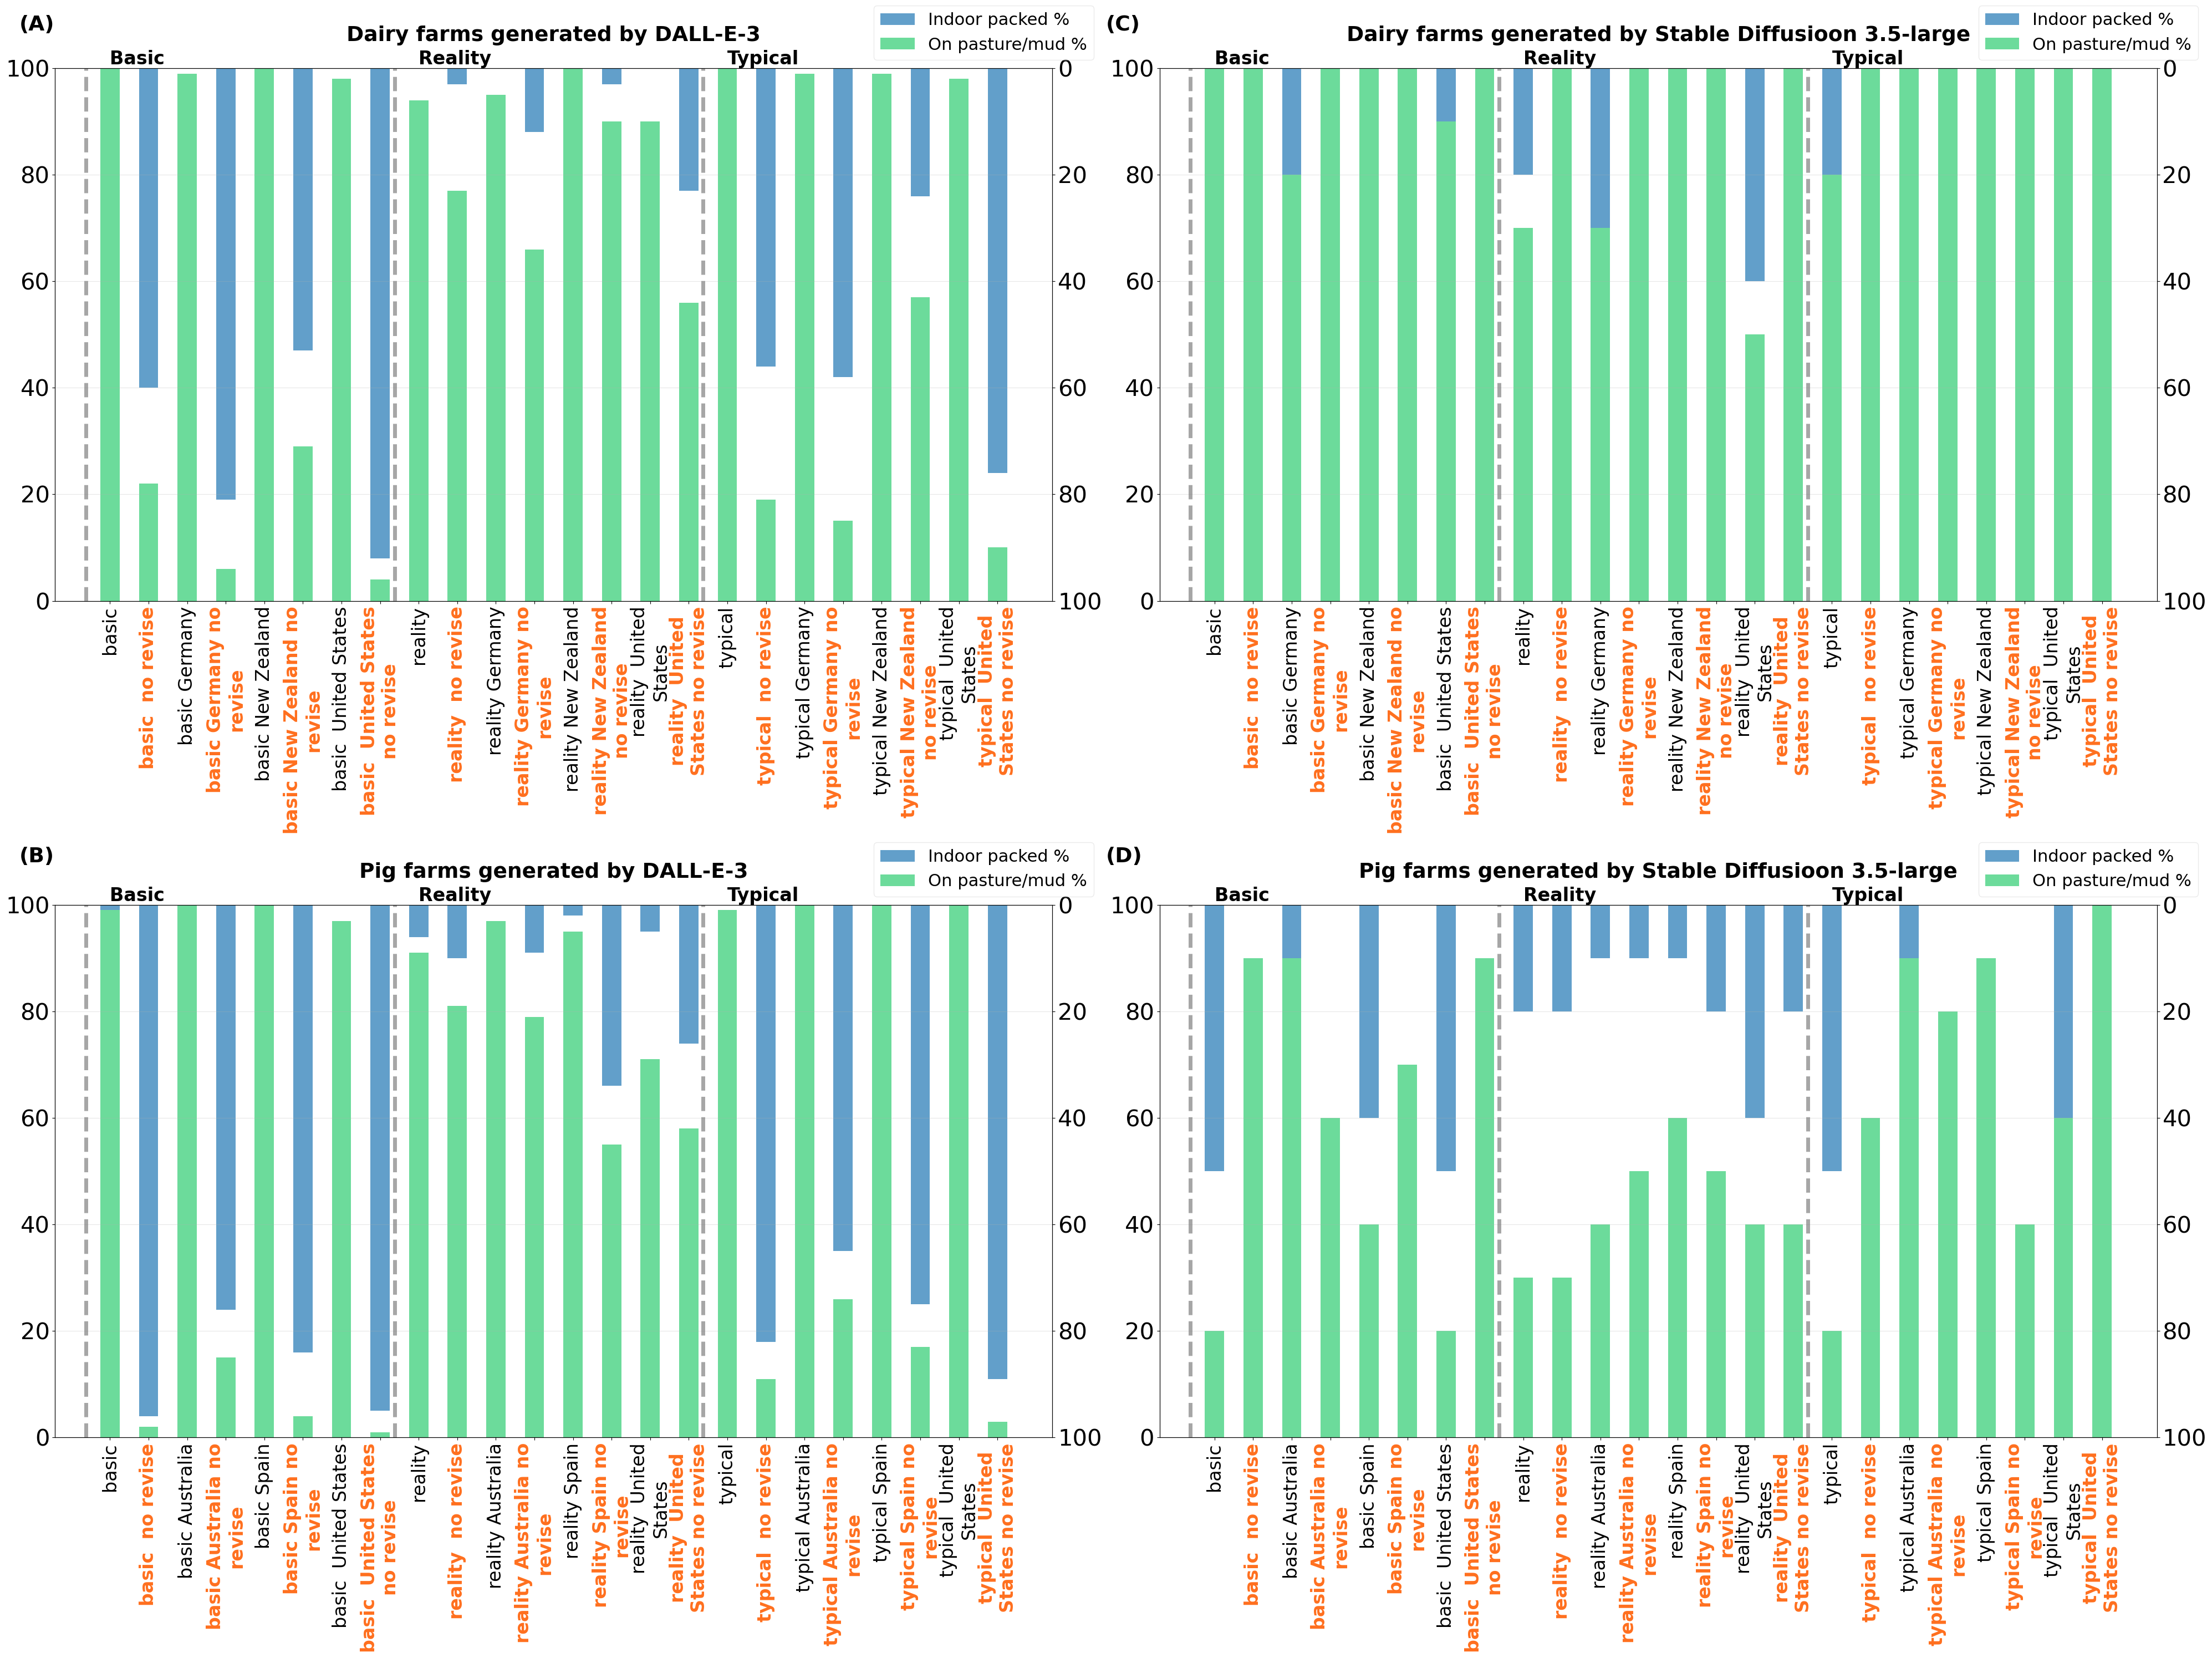

In [42]:
output_path = Path("..") / "results" / "plots" / "cluster_summary.png"
fig = module5_extract_pic_feature_words.save_plot_grid(cluster_summary, output_path)
fig